Figure saved to: F:\Dissertation\picts\cuasmrl_analysis\cuasmrl_vs_triton_execution_time.pdf


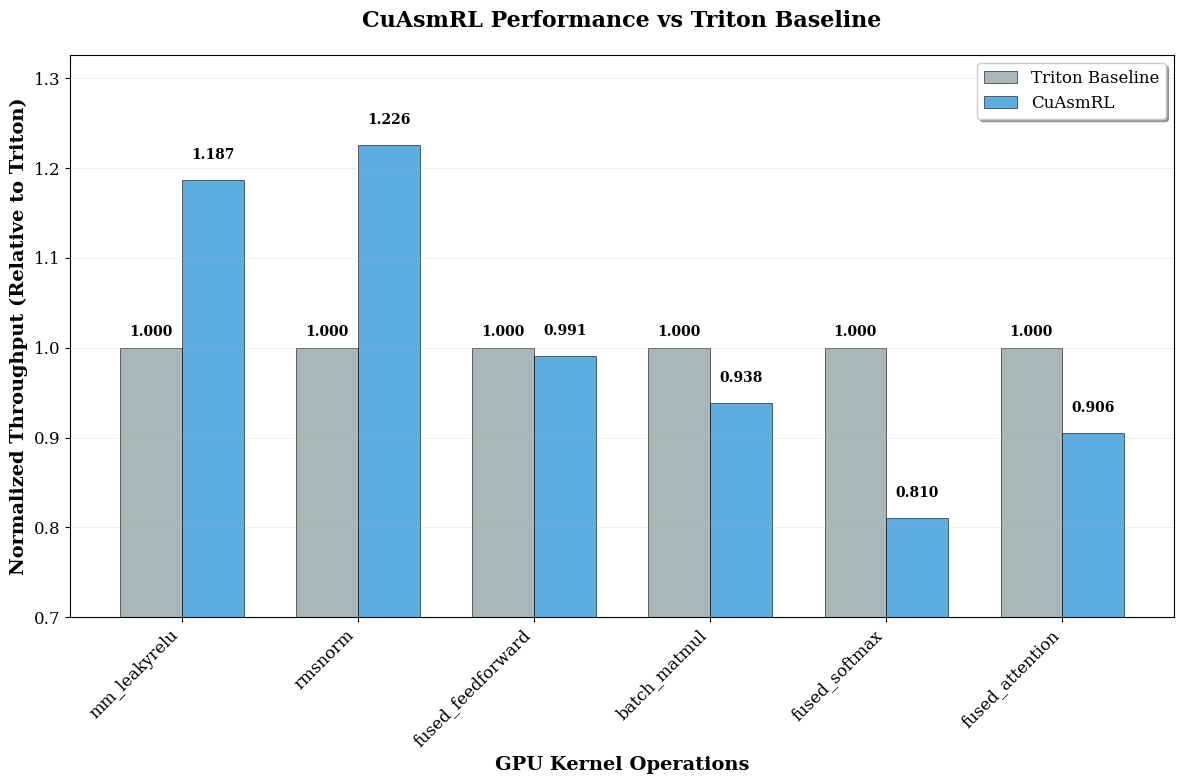


=== CuAsmRL Performance Statistics ===
Average performance improvement: 0.97%
Maximum performance improvement: 22.62% (rmsnorm)
Minimum performance improvement: -18.97% (fused_softmax)
Geometric mean speedup: 0.999x

=== Detailed Results ===
mm_leakyrelu:
  Triton baseline: 13.80 ms
  CuAsmRL average: 16.38 ms
  Performance ratio: 1.187
  Improvement: +18.69%

rmsnorm:
  Triton baseline: 73.46 ms
  CuAsmRL average: 90.08 ms
  Performance ratio: 1.226
  Improvement: +22.62%

fused_feedforward:
  Triton baseline: 4.71 ms
  CuAsmRL average: 4.67 ms
  Performance ratio: 0.991
  Improvement: -0.89%

batch_matmul:
  Triton baseline: 27.81 ms
  CuAsmRL average: 26.09 ms
  Performance ratio: 0.938
  Improvement: -6.18%

fused_softmax:
  Triton baseline: 419.53 ms
  CuAsmRL average: 339.93 ms
  Performance ratio: 0.810
  Improvement: -18.97%

fused_attention:
  Triton baseline: 64.94 ms
  CuAsmRL average: 58.81 ms
  Performance ratio: 0.906
  Improvement: -9.44%



In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cuasmrl_performance(save_path=None):
    """
    Plot CuAsmRL performance vs Triton baseline using execution time data
    
    Parameters:
    save_path (str): Path to save the figure, e.g., 'cuasmrl_vs_triton.pdf'
    """
    
    # Triton baseline results (average of 5 runs)
    triton_baseline = {
        'mm_leakyrelu': (11.72 + 14.61 + 12.57 + 10.15 + 19.97) / 5,  # ~13.80
        'rmsnorm': (74.75 + 72.90 + 73.27 + 72.88 + 73.51) / 5,  # ~73.46
        'fused_feedforward': (3.57 + 5.21 + 4.01 + 4.92 + 5.84) / 5,  # ~4.71
        'batch_matmul': (19.89 + 29.36 + 30.54 + 27.13 + 32.15) / 5,  # ~27.81
        'fused_softmax': (483.13 + 551.52 + 378.93 + 434.56 + 249.53) / 5,  # ~419.53
        'fused_attention': (53.42 + 70.60 + 69.76 + 63.97 + 66.95) / 5  # ~64.94
    }
    
    # CuAsmRL results (average of 5 runs)
    cuasmrl_results = {
        'mm_leakyrelu': [15.94, 13.75, 18.80, 13.55, 19.88],
        'rmsnorm': [91.43, 81.80, 92.30, 92.34, 92.53],
        'fused_feedforward': [4.81, 4.93, 4.32, 3.98, 5.30],
        'batch_matmul': [27.91, 28.91, 29.01, 23.82, 20.82],
        'fused_softmax': [350.73, 316.86, 351.42, 303.53, 377.11],
        'fused_attention': [65.37, 54.92, 58.37, 55.03, 60.36]
    }
    
    # Calculate performance ratios (CuAsmRL average / Triton average)
    performance_ratios = {}
    for kernel in triton_baseline.keys():
        triton_avg = triton_baseline[kernel]
        cuasmrl_avg = np.mean(cuasmrl_results[kernel])
        performance_ratios[kernel] = cuasmrl_avg / triton_avg
    
    # Prepare data for plotting
    kernels = list(performance_ratios.keys())
    performance_values = list(performance_ratios.values())
    triton_normalized = [1.0] * len(kernels)  # Triton baseline normalized to 1.0
    
    # Set figure parameters
    plt.figure(figsize=(12, 8))
    plt.rcParams['font.size'] = 12
    plt.rcParams['font.family'] = 'serif'
    
    # Set bar positions
    x = np.arange(len(kernels))
    width = 0.35
    
    # Create bar plots
    bars1 = plt.bar(x - width/2, triton_normalized, width, 
                   label='Triton Baseline', 
                   color='#95a5a6', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    bars2 = plt.bar(x + width/2, performance_values, width,
                   label='CuAsmRL', 
                   color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # Set labels and title
    plt.xlabel('GPU Kernel Operations', fontsize=14, fontweight='bold')
    plt.ylabel('Normalized Throughput (Relative to Triton)', fontsize=14, fontweight='bold')
    plt.title('CuAsmRL Performance vs Triton Baseline', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Set x-axis labels
    plt.xticks(x, kernels, rotation=45, ha='right')
    
    # Set y-axis range and ticks
    y_min = 0.7
    y_max = max(performance_values) + 0.1
    plt.ylim(y_min, y_max)
    
    # Create appropriate y-ticks
    y_ticks = np.arange(0.7, y_max + 0.01, 0.1)
    plt.yticks(y_ticks, [f'{y:.1f}' for y in y_ticks])
    
    # Add value labels on bars
    def add_value_labels(bars, values, offset=0.02):
        for bar, value in zip(bars, values):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + offset,
                    f'{value:.3f}',  # Show 3 decimal places for precision
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    add_value_labels(bars1, triton_normalized, offset=0.01)
    add_value_labels(bars2, performance_values, offset=0.02)
    
    # Add legend
    plt.legend(loc='upper right', frameon=True, shadow=True)
    
    # Add grid
    plt.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    if save_path:
        import os
        
        # Set save directory
        save_dir = r'F:\Dissertation\picts\cuasmrl_analysis'
        os.makedirs(save_dir, exist_ok=True)
        
        # Get filename
        filename = os.path.basename(save_path)
        
        # Ensure PDF format
        if not filename.endswith('.pdf'):
            filename = filename.rsplit('.', 1)[0] + '.pdf'
        
        # Build full save path
        full_save_path = os.path.join(save_dir, filename)
        
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight', 
                    facecolor='white', edgecolor='none',
                    format='pdf')
        print(f"Figure saved to: {full_save_path}")
    
    # Show figure
    plt.show()
    
    # Calculate statistics
    improvements = [(v - 1.0) * 100 for v in performance_values]
    avg_improvement = np.mean(improvements)
    max_improvement = max(improvements)
    min_improvement = min(improvements)
    
    print("\n=== CuAsmRL Performance Statistics ===")
    print(f"Average performance improvement: {avg_improvement:.2f}%")
    print(f"Maximum performance improvement: {max_improvement:.2f}% ({kernels[performance_values.index(max(performance_values))]})")
    print(f"Minimum performance improvement: {min_improvement:.2f}% ({kernels[performance_values.index(min(performance_values))]})")
    print(f"Geometric mean speedup: {np.exp(np.mean(np.log(performance_values))):.3f}x")
    
    # Print detailed results
    print("\n=== Detailed Results ===")
    for kernel, ratio in performance_ratios.items():
        improvement = (ratio - 1.0) * 100
        triton_avg = triton_baseline[kernel]
        cuasmrl_avg = np.mean(cuasmrl_results[kernel])
        print(f"{kernel}:")
        print(f"  Triton baseline: {triton_avg:.2f} ms")
        print(f"  CuAsmRL average: {cuasmrl_avg:.2f} ms") 
        print(f"  Performance ratio: {ratio:.3f}")
        print(f"  Improvement: {improvement:+.2f}%")
        print()
    
    # Return data for further analysis
    return {
        'kernels': kernels,
        'performance_ratios': performance_values,
        'improvements_percent': improvements,
        'avg_improvement': avg_improvement,
        'max_improvement': max_improvement,
        'min_improvement': min_improvement,
        'triton_baseline': triton_baseline,
        'cuasmrl_averages': {k: np.mean(v) for k, v in cuasmrl_results.items()}
    }

# Usage
if __name__ == "__main__":
    # Plot performance comparison
    results = plot_cuasmrl_performance(save_path='cuasmrl_vs_triton_execution_time.pdf')

C:\Users\lixin\AppData\Local\Temp\ipykernel_46904\3271271283.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


Corrected box plot saved to: F:\Dissertation\picts\cuasmrl_analysis\corrected_performance_boxplot.pdf


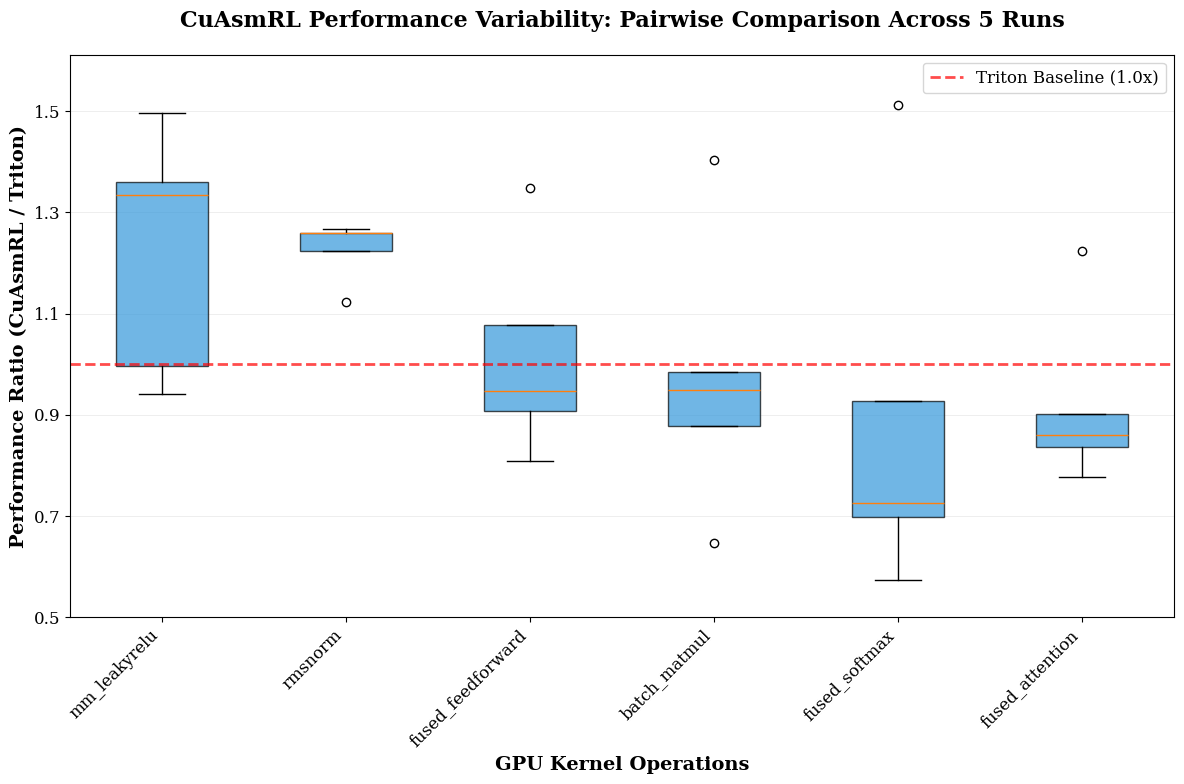


=== Performance Variability Statistics (Pairwise Comparison) ===
Kernel               Mean Ratio   Std Dev    CV (%)   Range               
--------------------------------------------------------------------------------
mm_leakyrelu         1.225        0.218      17.76    0.941-1.496         
rmsnorm              1.226        0.054      4.42     1.122-1.267         
fused_feedforward    1.017        0.186      18.28    0.809-1.347         
batch_matmul         0.973        0.245      25.21    0.648-1.403         
fused_softmax        0.888        0.332      37.39    0.575-1.511         
fused_attention      0.920        0.157      17.07    0.778-1.224         

=== Detailed Pairwise Ratios ===

mm_leakyrelu:
  Performance ratios: ['1.360', '0.941', '1.496', '1.335', '0.995']
  Improvement %: ['36.0%', '-5.9%', '49.6%', '33.5%', '-0.5%']
  Mean improvement: -8.0%

rmsnorm:
  Performance ratios: ['1.223', '1.122', '1.260', '1.267', '1.259']
  Improvement %: ['22.3%', '12.2%', '26.0%',

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_corrected_performance_boxplot(save_path=None):
    """
    Plot box plot showing CuAsmRL performance improvement relative to Triton baseline
    使用正确的逐次比较方法
    """
    # 每次实验的原始数据，而不是平均值
    triton_baseline = {
        'mm_leakyrelu': [11.72, 14.61, 12.57, 10.15, 19.97],
        'rmsnorm': [74.75, 72.90, 73.27, 72.88, 73.51],
        'fused_feedforward': [3.57, 5.21, 4.01, 4.92, 5.84],
        'batch_matmul': [19.89, 29.36, 30.54, 27.13, 32.15],
        'fused_softmax': [483.13, 551.52, 378.93, 434.56, 249.53],
        'fused_attention': [53.42, 70.60, 69.76, 63.97, 66.95]
    }
    
    cuasmrl_results = {
        'mm_leakyrelu': [15.94, 13.75, 18.80, 13.55, 19.88],      
        'rmsnorm': [91.43, 81.80, 92.30, 92.34, 92.53],      
        'fused_feedforward': [4.81, 4.93, 4.32, 3.98, 5.30],      
        'batch_matmul': [27.91, 28.91, 29.01, 23.82, 20.82],     
        'fused_softmax': [350.73, 316.86, 351.42, 303.53, 377.11],      
        'fused_attention': [65.37, 54.92, 58.37, 55.03, 60.36]    
    }
    
    # 计算相对于Triton的改进倍数 - 正确的逐次比较
    improvement_ratios = {}
    for kernel in cuasmrl_results.keys():
        triton_perfs = triton_baseline[kernel]
        cuasmrl_perfs = cuasmrl_results[kernel]
        # 每次CuAsmRL结果除以对应的那次Triton结果
        ratios = [cuasmrl_perfs[i] / triton_perfs[i] for i in range(len(cuasmrl_perfs))]
        improvement_ratios[kernel] = ratios
    
    plt.figure(figsize=(12, 8))
    plt.rcParams['font.size'] = 12
    plt.rcParams['font.family'] = 'serif'
    
    # 准备箱线图数据
    data_to_plot = [improvement_ratios[kernel] for kernel in improvement_ratios.keys()]
    labels = list(improvement_ratios.keys())
    
    # 创建箱线图
    box_plot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)
    
    # 美化箱线图
    colors = ['#3498db', '#3498db', '#3498db', '#3498db', '#3498db', '#3498db']
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # 添加基准线
    plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label='Triton Baseline (1.0x)')
    
    # 设置标签和标题
    plt.xlabel('GPU Kernel Operations', fontsize=14, fontweight='bold')
    plt.ylabel('Performance Ratio (CuAsmRL / Triton)', fontsize=14, fontweight='bold')
    plt.title('CuAsmRL Performance Variability: Pairwise Comparison Across 5 Runs', 
              fontsize=16, fontweight='bold', pad=20)
    
    # 动态调整Y轴范围
    all_values = [val for ratios in improvement_ratios.values() for val in ratios]
    y_min = min(all_values) - 0.05
    y_max = max(all_values) + 0.1
    plt.ylim(y_min, y_max)
    
    # 设置Y轴刻度
    y_tick_spacing = 0.1 if (y_max - y_min) < 1.0 else 0.2
    y_ticks = np.arange(np.floor(y_min * 10) / 10, y_max + 0.01, y_tick_spacing)
    plt.yticks(y_ticks, [f'{tick:.1f}' for tick in y_ticks])
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    
    # 保存图片
    if save_path:
        import os
        save_dir = r'F:\Dissertation\picts\cuasmrl_analysis'
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.basename(save_path)
        if not filename.endswith('.pdf'):
            filename = filename.rsplit('.', 1)[0] + '.pdf'
        full_save_path = os.path.join(save_dir, filename)
        plt.savefig(full_save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none', format='pdf')
        print(f"Corrected box plot saved to: {full_save_path}")
    
    plt.show()
    
    # 打印统计信息
    print("\n=== Performance Variability Statistics (Pairwise Comparison) ===")
    print(f"{'Kernel':<20} {'Mean Ratio':<12} {'Std Dev':<10} {'CV (%)':<8} {'Range':<20}")
    print("-" * 80)
    
    for kernel, ratios in improvement_ratios.items():
        mean_ratio = np.mean(ratios)
        std_ratio = np.std(ratios)
        cv = (std_ratio / mean_ratio) * 100
        range_str = f"{min(ratios):.3f}-{max(ratios):.3f}"
        
        print(f"{kernel:<20} {mean_ratio:<12.3f} {std_ratio:<10.3f} {cv:<8.2f} {range_str:<20}")
    
    print(f"\n=== Detailed Pairwise Ratios ===")
    for kernel, ratios in improvement_ratios.items():
        improvement_pcts = [(r-1)*100 for r in ratios]
        print(f"\n{kernel}:")
        print(f"  Performance ratios: {[f'{r:.3f}' for r in ratios]}")
        print(f"  Improvement %: {[f'{p:.1f}%' for p in improvement_pcts]}")
        print(f"  Mean improvement: {(mean_ratio-1)*100:.1f}%")
    
    # 返回结果用于进一步分析
    return improvement_ratios

# Usage
if __name__ == "__main__":
    ratios = plot_corrected_performance_boxplot(save_path='corrected_performance_boxplot.pdf')

C:\Users\lixin\AppData\Local\Temp\ipykernel_46904\3625846185.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


Box plot saved to: F:\Dissertation\picts\cuasmrl_analysis\cuasmrl_variability_boxplot.pdf


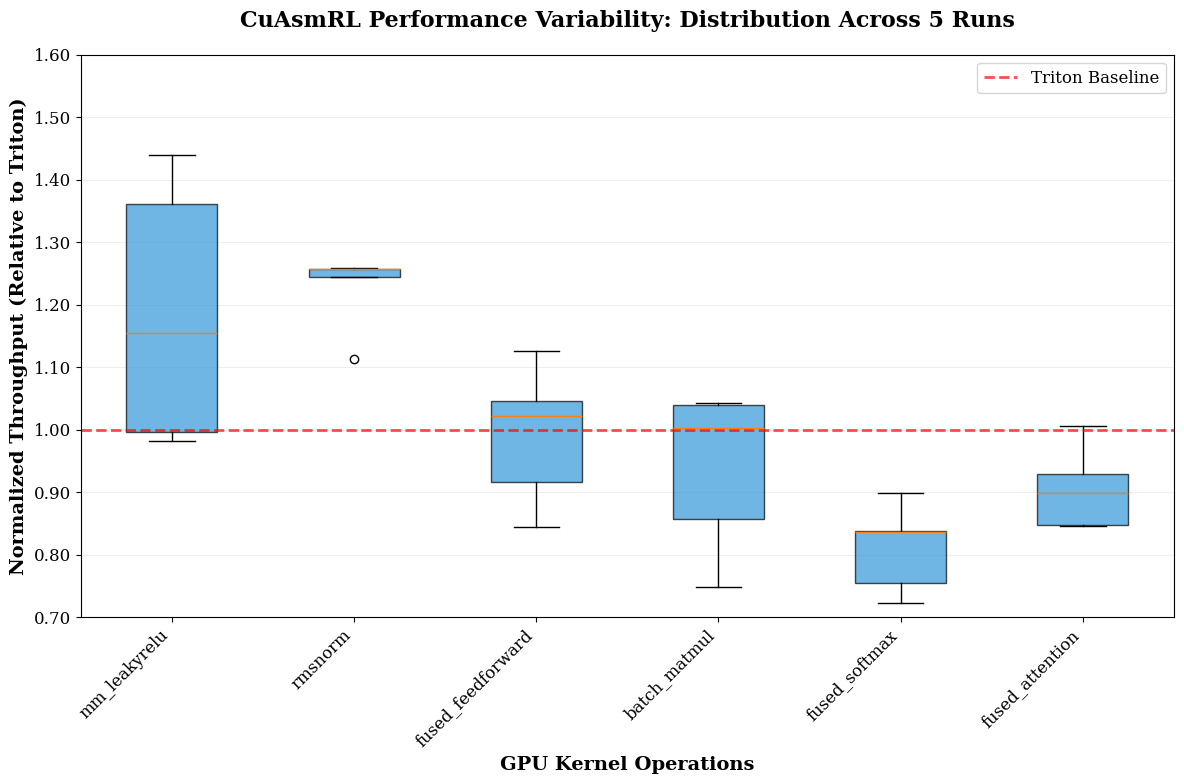


=== Performance Variability Statistics (按脚本顺序) ===
mm_leakyrelu:
  Mean improvement: 18.69%
  Std deviation: 0.187
  Coefficient of variation: 15.73%
  Range: 0.982 - 1.440

rmsnorm:
  Mean improvement: 22.62%
  Std deviation: 0.057
  Coefficient of variation: 4.62%
  Range: 1.114 - 1.260

fused_feedforward:
  Mean improvement: -0.89%
  Std deviation: 0.099
  Coefficient of variation: 9.97%
  Range: 0.845 - 1.125

batch_matmul:
  Mean improvement: -6.18%
  Std deviation: 0.117
  Coefficient of variation: 12.44%
  Range: 0.749 - 1.043

fused_softmax:
  Mean improvement: -18.97%
  Std deviation: 0.063
  Coefficient of variation: 7.77%
  Range: 0.723 - 0.899

fused_attention:
  Mean improvement: -9.44%
  Std deviation: 0.060
  Coefficient of variation: 6.59%
  Range: 0.846 - 1.007



In [9]:
plot_performance_boxplot(save_path='cuasmrl_variability_boxplot.pdf')